In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load raw dataset
df = pd.read_csv("../data/raw/customer_churn.csv")

In [3]:
# Parse date and create days since last purchase
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])
latest_date = df['Last_Purchase_Date'].max()
df['Days_Since_Last_Purchase'] = (latest_date - df['Last_Purchase_Date']).dt.days

In [4]:
# Recreate engineered scores (same as Phase 2/3)
df['Engagement_Score'] = (
    df['Website_Visits_Last_Month'] * 0.4 +
    df['Avg_Time_Per_Visit_Minutes'] * 0.4 +
    df['Referred_Friends'] * 0.2
)

df['Customer_Value_Score'] = (
    df['Total_Purchases'] * 0.5 +
    df['Avg_Purchase_Value'] * 0.5
)

df['Service_Risk_Score'] = (
    df['Support_Tickets_Last_6_Months'] * 0.7 +
    (5 - df['Satisfaction_Score']) * 0.3
)

df.shape

(9000, 21)

In [5]:
total_customers = len(df)
churned_customers = df['Churn'].sum()

churn_rate = churned_customers / total_customers * 100
churn_rate


np.float64(19.733333333333334)

## Customer Churn Distribution

Visualizing the overall proportion of retained and churned customers provides a quick understanding of the class distribution in the dataset.

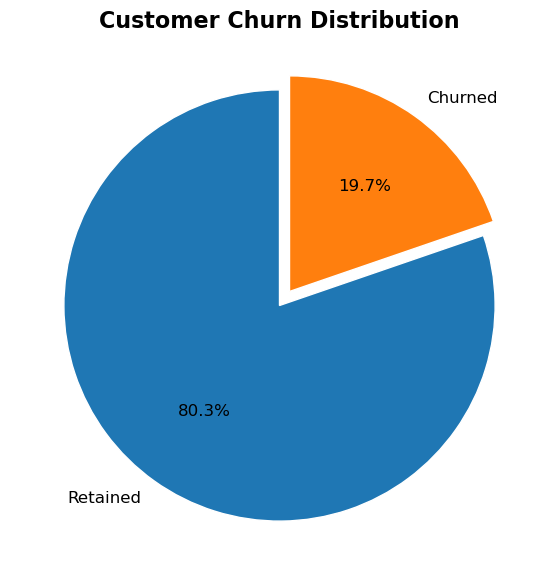

In [12]:
import matplotlib.pyplot as plt
import os

os.makedirs("../images", exist_ok=True)

# Count customers
churn_counts = df["Churn"].value_counts()

labels = ["Retained", "Churned"]

# Plot
plt.figure(figsize=(7,7))

plt.pie(
    churn_counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0, 0.08),
    textprops={"fontsize":12},
    wedgeprops={"edgecolor":"white"}
)

plt.title(
    "Customer Churn Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "../images/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
avg_customer_value = df['Customer_Value_Score'].mean()
avg_customer_value


np.float64(137.03091333333333)

In [7]:
risk_threshold = df['Service_Risk_Score'].quantile(0.75)
risk_threshold


np.float64(2.2499999999999996)

In [8]:
df['High_Risk_Flag'] = (df['Service_Risk_Score'] >= risk_threshold).astype(int)

high_risk_count = df['High_Risk_Flag'].sum()
high_risk_count

np.int64(2277)

In [9]:
revenue_at_risk = df.loc[df['High_Risk_Flag'] == 1, 'Customer_Value_Score'].sum()
revenue_at_risk

np.float64(310202.91)

In [10]:
churn_by_membership = (
    df.groupby('Membership_Status')['Churn']
      .mean()
      .reset_index()
      .sort_values(by='Churn', ascending=False)
)

churn_by_membership


,Membership_Status,Churn
3,Silver,0.208705
0,Bronze,0.196553
1,Gold,0.188628
2,Platinum,0.183973


## Customer Churn Rate by Membership Status

This visualization compares the churn rate across different membership tiers to identify which customer segments are more likely to churn.

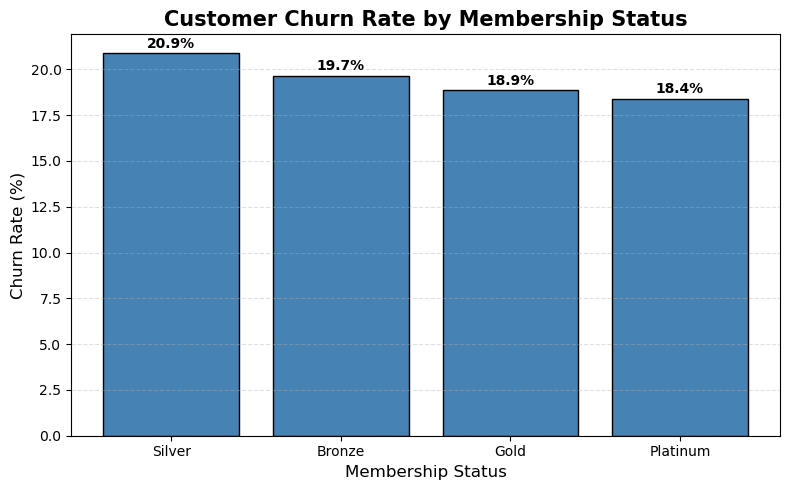

In [13]:
os.makedirs("../images", exist_ok=True)

# Convert churn rate to percentage
plot_data = churn_by_membership.copy()
plot_data["Churn (%)"] = plot_data["Churn"] * 100

plt.figure(figsize=(8,5))

bars = plt.bar(
    plot_data["Membership_Status"],
    plot_data["Churn (%)"],
    color="steelblue",
    edgecolor="black"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Customer Churn Rate by Membership Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Membership Status", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../images/churn_by_membership.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
revenue_risk_by_membership = (
    df[df['High_Risk_Flag'] == 1]
    .groupby('Membership_Status')['Customer_Value_Score']
    .sum()
    .reset_index()
    .sort_values(by='Customer_Value_Score', ascending=False)
)

revenue_risk_by_membership


,Membership_Status,Customer_Value_Score
0,Bronze,122352.600
3,Silver,93756.090
1,Gold,63459.765
2,Platinum,30634.455


## Revenue at Risk by Membership Status

This chart shows which membership segments contribute the highest potential revenue loss among high-risk customers.

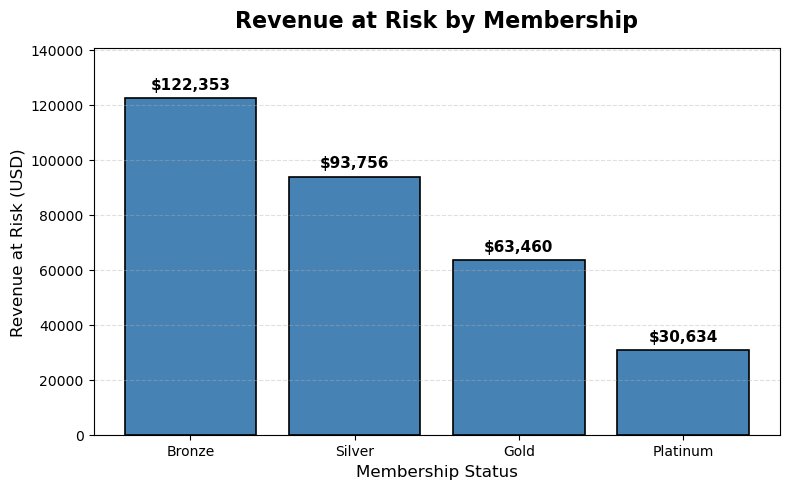

In [16]:
os.makedirs("../images", exist_ok=True)

plt.figure(figsize=(8,5))

bars = plt.bar(
    revenue_risk_by_membership["Membership_Status"],
    revenue_risk_by_membership["Customer_Value_Score"],
    color="steelblue",
    edgecolor="black",
    linewidth=1.2
)

max_value = revenue_risk_by_membership["Customer_Value_Score"].max()
plt.ylim(0, max_value * 1.15)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + max_value * 0.02,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Revenue at Risk by Membership",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Membership Status", fontsize=12)
plt.ylabel("Revenue at Risk (USD)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../images/revenue_at_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Business KPIs Summary

- Overall churn rate indicates that approximately one in five customers are lost, highlighting a significant retention opportunity.
- A subset of customers was classified as high risk based on service-related and engagement signals, enabling focused retention efforts.
- Revenue-at-risk analysis quantified the potential financial impact of churn, translating customer behavior into business value.
- Segment-level analysis revealed membership tiers with elevated churn and revenue exposure, supporting targeted retention strategies.



### KPI Analysis & Business Insights

The overall customer churn rate was approximately 19.7%, indicating that nearly one in five customers discontinue usage, representing a significant retention opportunity.

High-risk customers were identified using a service-risk-based threshold (75th percentile), resulting in 2,277 customers flagged for potential churn. Revenue-at-risk analysis estimated a potential exposure of approximately 310K, translating churn behavior into direct financial impact.

Segment-level analysis revealed that Silver and Bronze membership tiers exhibit higher churn rates compared to premium tiers, while Bronze members contribute the highest revenue at risk. These findings suggest that targeted retention strategies focused on lower-tier memberships could yield substantial business value.

Overall, the KPI framework enabled actionable insights by connecting customer behavior, churn risk, and revenue impact in a decision-oriented manner.
